
# C 题问题 1：微网计划购电与储能优化——完整建模、求解与检验

本 notebook 在原有求解方案上重新组织叙述，不改变问题 1 的模型口径和提交结果。全文按照以下证据链展开：

> **问题分析 → 数据预处理（清洗）→ 探索性数据分析（EDA）→ 模型建立 → 模型求解 → 结果分析 → 模型检验 → 敏感性分析**

所有功率、电量、成本和约束检验均由代码实际计算。运行本 notebook 后将同步生成 `result1.xlsx`、机器可读结果表和论文可用的 PDF 矢量图。

---



## 1. 问题分析

### 1.1 任务理解

微网在一天内同时具有小区负荷、光伏发电和储能系统。已知每个 10 分钟时段的负荷预测功率、光伏预测功率和分时电价，需要决定：

1. 每个时段从大电网购买多少电量；
2. 每个时段给储能充入多少电量；
3. 每个时段从储能放出多少电量；
4. 每个时段结束时储能中保有多少电量。

目标是在满足负荷供电和储能物理约束的条件下，使全天计划购电费用最小。题目还要求给出指定 10 分钟时段的购电量、六个 4 小时时段的充放电量，以及日初、日末储能电量。

### 1.2 输入、输出与评价标准

| 类别 | 内容 |
|---|---|
| 输入 | 144 个 10 分钟时段的电价、负荷预测功率、光伏预测功率；储能容量、SOC 范围、充放电功率与效率 |
| 决策输出 | 各时段计划购电量、充电量、放电量和 SOC 轨迹 |
| 汇总输出 | 指定时段购电量、六个 4 小时块的充放电量、首尾 SOC、全天费用 |
| 核心目标 | 最小化全天计划购电费 |
| 可行性标准 | 供需平衡、SOC 递推、容量界、功率界、非负性和首尾一致全部满足 |
| 最优性标准 | 求解器返回最优状态，原始—对偶间隙接近 0 |
| 经济性标准 | 相比无储能和简单峰谷规则，购电成本显著下降 |
| 稳定性标准 | 效率、功率和容量扰动后结论方向合理且始终可行 |

### 1.3 建模难点

- 原始数据给出的是 **kW 功率**，而电费、SOC 和充放电量需要用 **kWh 电量** 表示，必须统一量纲。
- 光伏可能超过负荷，需要允许弃光，否则部分时段会被错误判为不可行。
- 储能有损耗，SOC 递推中充电和放电不能使用同一个符号或同一种效率写法。
- 日末 SOC 必须回到初值，否则模型会通过“耗尽电池”虚假降低当日成本。
- 需要证明为什么是线性规划，并对全局最优、物理可行和经济有效分别给出证据。

### 1.4 关键歧义与最终口径

1. **时间标签。** 附件中的 `00:10` 表示自然区间 `00:00—00:10` 的右端点，最后一行 `0:00+1` 表示次日 00:00。模型按原始行序对应自然区间，不擅自平移提交模板列。
2. **效率。** “充放电效率 90%”按单向效率解释，即 $\eta_c=\eta_d=0.9$，往返效率为 $0.9^2=0.81$。敏感性分析另行改变效率。
3. **光伏富余。** 允许免费弃光，但不允许向外部电网反向售电。因此购电量非负，供给可以大于用电，多出的电量记为弃电/弃光。
4. **初末 SOC。** 额定容量为 12,000 kWh，运行区间为 10%—90%，日初和日末均固定为 50%，即 6,000 kWh。
5. **电池退化。** 题目没有提供循环寿命或退化成本，主目标不加入虚构参数；仅加入 $10^{-8}$ 的吞吐量破平项，排除数值上无意义的等价充放电。
6. **电网购电上限。** 题目没有给出变压器或联络线容量，故只设置 $g_t\ge0$，不虚构购电功率上限。若工程应用中已知并网容量 $G_{\max}$，可直接增加 $g_t\le G_{\max}\Delta t$。



## 2. 数据预处理与清洗

### 2.1 清洗原则

建模前依次检查 Excel 工作表、行列数、字段名、公式单元格、合并单元格、隐藏行列、缺失值、重复时间、非有限数、负负荷、负光伏和非正电价。只有确有错误时才修正或插补；本题数据完整，因此不为了“清洗”而改变原始数值。

### 2.2 单位统一

时间步长为

$$
\Delta t=\frac{10}{60}=\frac16\ \text{h}.
$$

若原始负荷功率、光伏功率分别为 $L_t$ 和 $P_t^{\mathrm{PV}}$（kW），则一个时段内的电量为

$$
L_t^{E}=L_t\Delta t,\qquad
P_t^{E,\mathrm{PV}}=P_t^{\mathrm{PV}}\Delta t,
$$

单位均为 kWh。此后，购电量、充电量、放电量和 SOC 都统一用 kWh 表示；绘制日内曲线时再除以 $\Delta t$ 还原为 kW。


In [1]:

from pathlib import Path
import json, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from scipy.sparse import lil_matrix
from openpyxl import load_workbook
from IPython.display import display

warnings.filterwarnings('ignore')
np.set_printoptions(precision=6, suppress=True)
pd.set_option('display.max_columns', 30)

def locate_root():
    # 允许从项目根目录或 code/ 目录启动 notebook。
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'C题/附件/附件1.xlsx').exists():
            return candidate
    raise FileNotFoundError('未找到 C题/附件/附件1.xlsx')

ROOT = locate_root()
DATA_PATH = ROOT / 'C题/附件/附件1.xlsx'
TEMPLATE_PATH = ROOT / 'C题/附件/附件5/result1.xlsx'
RESULT_DIR = ROOT / 'results'
FIG_DIR = ROOT / 'figures'
RESULT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'font.sans-serif': ['PingFang SC', 'Heiti SC', 'Arial Unicode MS', 'DejaVu Sans'],
    'axes.unicode_minus': False, 'pdf.fonttype': 42, 'ps.fonttype': 42,
    'figure.dpi': 130, 'axes.grid': True, 'grid.alpha': 0.20,
})

DT = 1/6                 # h
N = 144                  # 144 个 10 分钟时槽
BASE_CAPACITY = 12000.0  # kWh
BASE_PMAX_KW = 5000.0    # kW
BASE_ETA_C = 0.90
BASE_ETA_D = 0.90
THROUGHPUT_EPS = 1e-8

print('项目根目录：', ROOT)


项目根目录： /content


In [2]:

# 读取 Excel 结构与原始表
wb_meta = load_workbook(DATA_PATH, data_only=False, read_only=False)
sheet_meta = []
for ws in wb_meta.worksheets:
    formula_count = sum(
        1 for row in ws.iter_rows() for cell in row
        if isinstance(cell.value, str) and cell.value.startswith('=')
    )
    hidden_rows = sum(bool(v.hidden) for v in ws.row_dimensions.values())
    hidden_cols = sum(bool(v.hidden) for v in ws.column_dimensions.values())
    sheet_meta.append({
        '工作表': ws.title, '最大行数': ws.max_row, '最大列数': ws.max_column,
        '公式单元格数': formula_count, '合并区域数': len(ws.merged_cells.ranges),
        '隐藏行数': hidden_rows, '隐藏列数': hidden_cols,
    })
wb_meta.close()

raw = pd.read_excel(DATA_PATH, sheet_name='Sheet1')
expected_columns = ['时间', '电价', '小区负载', '光伏发电预测功率']
assert raw.columns.tolist() == expected_columns

quality = pd.DataFrame([
    {'检查项': '数据形状', '结果': str(raw.shape), '通过条件': '(144, 4)'},
    {'检查项': '缺失单元格数', '结果': int(raw.isna().sum().sum()), '通过条件': '0'},
    {'检查项': '重复时间标签数', '结果': int(raw['时间'].astype(str).duplicated().sum()), '通过条件': '0'},
    {'检查项': '非有限数值数', '结果': int((~np.isfinite(raw[expected_columns[1:]].to_numpy(float))).sum()), '通过条件': '0'},
    {'检查项': '非正电价数', '结果': int((raw['电价'] <= 0).sum()), '通过条件': '0'},
    {'检查项': '负负荷数', '结果': int((raw['小区负载'] < 0).sum()), '通过条件': '0'},
    {'检查项': '负光伏数', '结果': int((raw['光伏发电预测功率'] < 0).sum()), '通过条件': '0'},
])

assert raw.shape == (N, 4)
assert raw.isna().sum().sum() == 0
assert raw['时间'].astype(str).duplicated().sum() == 0
assert np.isfinite(raw[expected_columns[1:]].to_numpy(float)).all()
assert (raw['电价'] > 0).all() and (raw['小区负载'] >= 0).all()
assert (raw['光伏发电预测功率'] >= 0).all()

# 数据没有错误，不做插值、删点或平滑；cleaned 与 raw 数值完全一致。
cleaned = raw.copy()
price = cleaned['电价'].to_numpy(float)
load_kw = cleaned['小区负载'].to_numpy(float)
pv_kw = cleaned['光伏发电预测功率'].to_numpy(float)
net_kw = load_kw - pv_kw
load_e, pv_e, net_e = load_kw*DT, pv_kw*DT, net_kw*DT
hours = np.arange(N)*DT

def clock_label(total_minutes):
    if total_minutes == 1440:
        return '24:00'
    return f'{total_minutes//60:02d}:{total_minutes%60:02d}'

natural_intervals = [f'{clock_label(10*t)}—{clock_label(10*(t+1))}' for t in range(N)]
energy_summary = pd.DataFrame([
    {'对象': '负荷', '全天电量_kWh': load_e.sum(), '最小功率_kW': load_kw.min(), '最大功率_kW': load_kw.max()},
    {'对象': '光伏', '全天电量_kWh': pv_e.sum(), '最小功率_kW': pv_kw.min(), '最大功率_kW': pv_kw.max()},
    {'对象': '净负荷', '全天电量_kWh': net_e.sum(), '最小功率_kW': net_kw.min(), '最大功率_kW': net_kw.max()},
])

pd.DataFrame(sheet_meta).to_csv(RESULT_DIR/'problem1_excel_structure.csv', index=False, encoding='utf-8-sig')
quality.to_csv(RESULT_DIR/'problem1_data_quality.csv', index=False, encoding='utf-8-sig')
energy_summary.to_csv(RESULT_DIR/'problem1_energy_summary.csv', index=False, encoding='utf-8-sig')

display(pd.DataFrame(sheet_meta))
display(quality)
display(energy_summary.round(4))
display(cleaned.head(3))
display(cleaned.tail(3))


,工作表,最大行数,最大列数,公式单元格数,合并区域数,隐藏行数,隐藏列数
0,Sheet1,145,4,0,0,0,0


,检查项,结果,通过条件
0,数据形状,"(144, 4)","(144, 4)"
1,缺失单元格数,0,0
2,重复时间标签数,0,0
3,非有限数值数,0,0
4,非正电价数,0,0
5,负负荷数,0,0
6,负光伏数,0,0


,对象,全天电量_kWh,最小功率_kW,最大功率_kW
0,负荷,111024.8081,3309.3934,5958.9696
1,光伏,55482.8357,0.0000,7612.3160
2,净负荷,55541.9724,-2117.5253,4956.4995


,时间,电价,小区负载,光伏发电预测功率
0,00:10:00,0.4248,3439.8466,0.0
1,00:20:00,0.4245,3437.9792,0.0
2,00:30:00,0.4269,3444.3031,0.0


,时间,电价,小区负载,光伏发电预测功率
141,23:40,0.4240,3429.6923,0.0
142,23:50,0.4271,3439.0610,0.0
143,0:00+1,0.4276,3444.7259,0.0



### 2.3 清洗结果解释

- 附件 1 只有 1 个工作表，含 145 行（1 行表头和 144 行数据）、4 列；没有公式、合并单元格或隐藏行列。
- 144 个时槽完整，无缺失值、重复时间、非有限数、非正电价、负负荷或负光伏，因此不需要插值、异常值删除或平滑。
- 负荷、光伏和净负荷全天电量分别为 111,024.81、55,482.84 和 55,541.97 kWh，且满足“负荷电量−光伏电量=净负荷电量”。
- 净负荷出现负值是中午光伏超过负荷的真实物理现象，不是异常值，不能删除。

---



## 3. 探索性数据分析（EDA）

EDA 回答四个直接影响建模的问题：

1. 负荷、光伏和净负荷的日内峰谷何时出现？
2. 分时电价与负荷、净负荷是否同步？
3. 光伏是否形成可由储能吸收的中午谷值？
4. 在考虑 81% 往返效率后，峰谷价差是否仍有套利空间？

采用电价的下四分位数 $Q_{25}$ 和上四分位数 $Q_{75}$ 将时段划分为低价、平价和高价三组。这一划分仅用于解释和规则 baseline，不进入完整 LP 的目标或约束。


,变量,最小值,最小时段,最大值,最大时段
0,负荷功率_kW,3309.3934,22:00—22:10,5958.9696,09:00—09:10
1,光伏功率_kW,0.0000,00:00—00:10,7612.3160,12:00—12:10
2,净负荷功率_kW,-2117.5253,12:00—12:10,4956.4995,17:30—17:40
3,电价_元每kWh,0.3713,05:30—05:40,1.3952,20:30—20:40


,指标,数值
0,电价极差_元每kWh,1.023900
1,电价与负荷相关系数,0.442535
2,电价与净负荷相关系数,0.093265
3,光伏与净负荷相关系数,-0.970110
4,低价电量考虑往返效率后的盈亏平衡高价_元每kWh,0.458395


负荷_kW                               光伏_kW                       \
         mean       min       max count      mean  min       max count   
电价带                                                                      
低价   3518.633  3309.393  5462.363    36   216.237  0.0  7472.738    36   
平价   5011.074  3412.956  5923.783    72  3419.295  0.0  7612.316    72   
高价   4963.353  4122.761  5958.970    36  2192.311  0.0  6599.381    36   

       净负荷_kW                            
         mean       min       max count  
电价带                                      
低价   3302.396 -2010.376  3546.398    36  
平价   1591.779 -2117.525  4956.500    72  
高价   2771.041  -701.902  4655.668    36

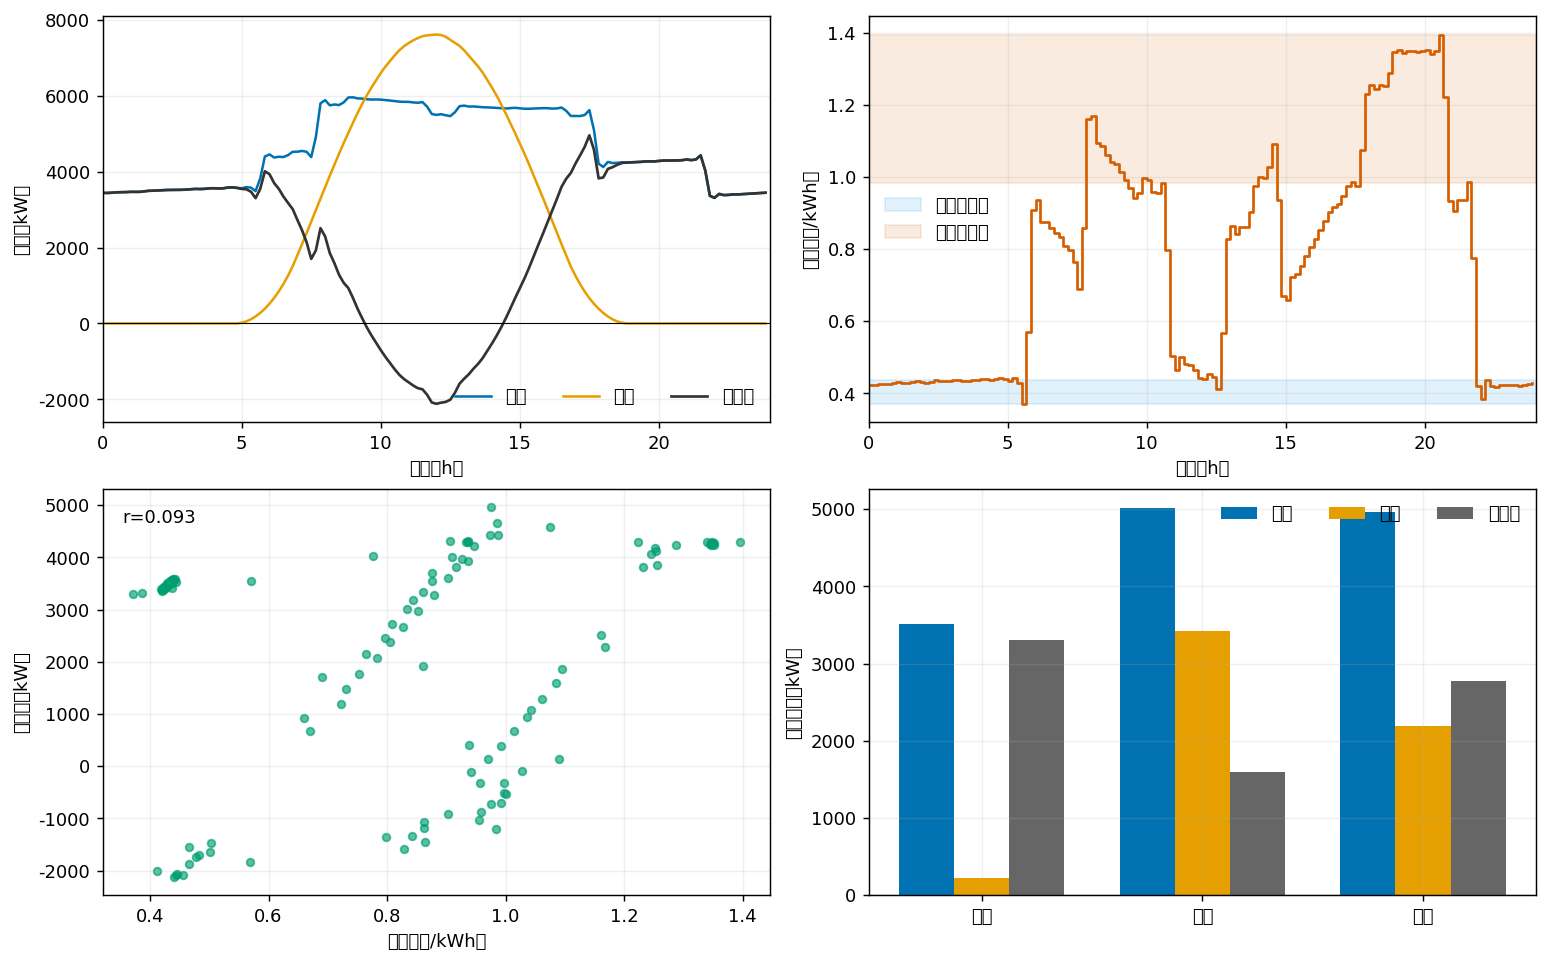

In [3]:

q25, q75 = np.quantile(price, [0.25, 0.75])
tariff_band = np.select([price <= q25, price >= q75], ['低价', '高价'], default='平价')

eda = pd.DataFrame({
    '时槽': np.arange(1, N+1), '自然时间段': natural_intervals, '时刻_h': hours,
    '负荷_kW': load_kw, '光伏_kW': pv_kw, '净负荷_kW': net_kw,
    '电价_元每kWh': price, '电价带': tariff_band,
})

def extrema_row(name, arr):
    imin, imax = int(np.argmin(arr)), int(np.argmax(arr))
    return {
        '变量': name, '最小值': float(arr[imin]), '最小时段': natural_intervals[imin],
        '最大值': float(arr[imax]), '最大时段': natural_intervals[imax],
    }

extrema = pd.DataFrame([
    extrema_row('负荷功率_kW', load_kw), extrema_row('光伏功率_kW', pv_kw),
    extrema_row('净负荷功率_kW', net_kw), extrema_row('电价_元每kWh', price),
])
band_summary = (eda.groupby('电价带')[['负荷_kW','光伏_kW','净负荷_kW']]
                .agg(['mean','min','max','count']).reindex(['低价','平价','高价']))
eda_metrics = pd.DataFrame([
    {'指标': '电价极差_元每kWh', '数值': price.max()-price.min()},
    {'指标': '电价与负荷相关系数', '数值': np.corrcoef(price, load_kw)[0,1]},
    {'指标': '电价与净负荷相关系数', '数值': np.corrcoef(price, net_kw)[0,1]},
    {'指标': '光伏与净负荷相关系数', '数值': np.corrcoef(pv_kw, net_kw)[0,1]},
    {'指标': '低价电量考虑往返效率后的盈亏平衡高价_元每kWh',
     '数值': price.min()/(BASE_ETA_C*BASE_ETA_D)},
])

extrema.to_csv(RESULT_DIR/'problem1_eda_extrema.csv', index=False, encoding='utf-8-sig')
band_summary.to_csv(RESULT_DIR/'problem1_tariff_band_summary.csv', encoding='utf-8-sig')
eda_metrics.to_csv(RESULT_DIR/'problem1_eda_metrics.csv', index=False, encoding='utf-8-sig')
display(extrema.round(4))
display(eda_metrics.round(6))
display(band_summary.round(3))

fig, axes = plt.subplots(2, 2, figsize=(11.8, 7.3), constrained_layout=True)

# (a) 三条日内功率曲线：识别光伏谷和傍晚峰
axes[0,0].plot(hours, load_kw, color='#0072B2', lw=1.4, label='负荷')
axes[0,0].plot(hours, pv_kw, color='#E69F00', lw=1.4, label='光伏')
axes[0,0].plot(hours, net_kw, color='#333333', lw=1.5, label='净负荷')
axes[0,0].axhline(0, color='black', lw=.6)
axes[0,0].set_xlabel('时刻（h）'); axes[0,0].set_ylabel('功率（kW）')
axes[0,0].set_xlim(0,24); axes[0,0].legend(frameon=False, ncol=3)

# (b) 分时电价及高低价区域
axes[0,1].step(hours, price, where='post', color='#D55E00', lw=1.5)
axes[0,1].axhspan(price.min(), q25, color='#56B4E9', alpha=.18, label='低价四分位')
axes[0,1].axhspan(q75, price.max(), color='#D55E00', alpha=.12, label='高价四分位')
axes[0,1].set_xlabel('时刻（h）'); axes[0,1].set_ylabel('电价（元/kWh）')
axes[0,1].set_xlim(0,24); axes[0,1].legend(frameon=False)

# (c) 电价—净负荷散点：检验二者是否简单线性同步
axes[1,0].scatter(price, net_kw, s=18, alpha=.65, color='#009E73')
axes[1,0].set_xlabel('电价（元/kWh）'); axes[1,0].set_ylabel('净负荷（kW）')
axes[1,0].text(.03,.95,f'r={np.corrcoef(price,net_kw)[0,1]:.3f}',
               transform=axes[1,0].transAxes, va='top')

# (d) 不同电价带下的平均功率结构
band_mean = eda.groupby('电价带')[['负荷_kW','光伏_kW','净负荷_kW']].mean().reindex(['低价','平价','高价'])
x = np.arange(3); width = .25
axes[1,1].bar(x-width, band_mean['负荷_kW'], width, color='#0072B2', label='负荷')
axes[1,1].bar(x, band_mean['光伏_kW'], width, color='#E69F00', label='光伏')
axes[1,1].bar(x+width, band_mean['净负荷_kW'], width, color='#666666', label='净负荷')
axes[1,1].axhline(0, color='black', lw=.6)
axes[1,1].set_xticks(x, band_mean.index); axes[1,1].set_ylabel('平均功率（kW）')
axes[1,1].legend(frameon=False, ncol=3)

for ax in axes.flat:
    ax.grid(alpha=.20)
fig.savefig(FIG_DIR/'problem1_eda.pdf', bbox_inches='tight')
plt.show()



### 3.1 EDA 图的含义与结论

上图四个子图分别承担不同论证任务，而不是简单重复同一数据。

- **左上图：负荷—光伏—净负荷的日内演变。** 负荷在 09:00—09:10 达到 5,958.97 kW；光伏在 12:00—12:10 达到 7,612.32 kW，使净负荷降至 -2,117.53 kW。17:30—17:40 光伏减弱后，净负荷回升到全天最高 4,956.50 kW。这说明储能应把中午富余能量跨时段转移到傍晚。
- **右上图：电价峰谷。** 电价最低为 0.3713 元/kWh，最高为 1.3952 元/kWh，峰谷差 1.0239 元/kWh。以双向效率 90% 计算，最低价电量的盈亏平衡高价为 $0.3713/0.81=0.4584$ 元/kWh，显著低于最高电价，存在充分的峰谷套利空间。
- **左下图：电价与净负荷关系。** 二者相关系数仅为 0.0933，说明“负荷高就一定电价高”的简单规则不足以求最优。储能价值来自跨时段耦合，必须联合考虑未来价格、SOC 和功率限制。
- **右下图：不同电价带的能量结构。** 该图比较低价、平价、高价时段的平均负荷、光伏和净负荷，为后文的固定峰谷规则 baseline 提供数据依据。

光伏与净负荷相关系数为 -0.9701，进一步证明中午光伏是净负荷谷的主要来源。因此，问题 1 同时包含“吸收光伏富余”和“峰谷电价套利”两类储能价值。

---



## 4. 模型建立

### 4.1 为什么选择线性规划

问题要求在已知单日负荷、光伏和电价的条件下最小化购电成本，属于确定性连续优化。购电费用是购电量的一次函数；电量平衡、SOC 递推、容量约束和功率约束也都是线性等式或不等式，且没有整数变量。因此模型是线性规划（Linear Programming, LP）。

| 候选方法 | 是否采用 | 原因 |
|---|---|---|
| 线性规划 LP | 采用 | 完全匹配线性结构，可直接得到全局最优和对偶认证 |
| 整数规划 MIP | 不采用 | 题目没有启停、台数等 0-1 决策，增加整数变量没有必要 |
| 非线性规划 NLP | 不采用 | 没有必须保留的非线性机理，人为非线性会削弱可解释性与最优性保证 |
| 动态规划 DP | 不采用 | 状态离散会引入网格误差，且本题 LP 已能精确求解 |
| GA / PSO | 不采用 | 只能给启发式近似，需调参，不能比 LP 提供更强的全局最优证明 |
| LSTM | 不采用 | LSTM 是预测模型；问题 1 已给定预测曲线，核心任务是优化而不是再预测 |

### 4.2 符号、参数和决策变量

下标 $t=0,1,\ldots,T-1$ 表示第 $t$ 个 10 分钟时段，$T=144$。

| 符号 | 类型 | 含义 | 单位 |
|---|---|---|---|
| $L_t$ | 已知参数 | 小区负荷预测功率 | kW |
| $P_t^{\mathrm{PV}}$ | 已知参数 | 光伏预测功率 | kW |
| $p_t$ | 已知参数 | 分时购电价格 | 元/kWh |
| $\Delta t$ | 已知参数 | 单时段长度，$1/6$ | h |
| $C$ | 已知参数 | 储能额定容量，12,000 | kWh |
| $P_{\max}$ | 已知参数 | 最大充/放电功率，5,000 | kW |
| $\eta_c,\eta_d$ | 已知参数 | 充、放电单向效率，均为 0.9 | — |
| $g_t$ | 决策变量 | 第 $t$ 时段计划购电量 | kWh |
| $c_t$ | 决策变量 | 第 $t$ 时段充入电池端的电量 | kWh |
| $d_t$ | 决策变量 | 第 $t$ 时段电池向负荷侧放出的电量 | kWh |
| $E_t$ | 状态/决策变量 | 第 $t$ 时段开始时的储能电量 | kWh |
| $s_t$ | 派生松弛量 | 弃电/弃光量，由最优解回代得到 | kWh |

### 4.3 电量平衡约束的推导

第 $t$ 个时段的可用电量由电网购电、光伏发电和储能放电构成；电量去向为负荷、储能充电和弃电。因此

$$
g_t + P_t^{\mathrm{PV}}\Delta t + d_t
= L_t\Delta t + c_t+s_t,\qquad s_t\ge 0.
$$

消去非负松弛量 $s_t$ 后得到代码中直接使用的不等式

$$
g_t+d_t-c_t\ge (L_t-P_t^{\mathrm{PV}})\Delta t.
$$

定义净负荷电量

$$
n_t=(L_t-P_t^{\mathrm{PV}})\Delta t,
$$

则供需约束可简写为 $g_t+d_t-c_t\ge n_t$。该形式允许光伏富余被弃用，但由于 $g_t\ge0$，不允许反向售电。

### 4.4 SOC 递推约束的推导

充入 $c_t$ kWh 时，真正存入电池的电量为 $\eta_c c_t$；向负荷侧放出 $d_t$ kWh 时，电池内部需要减少 $d_t/\eta_d$。因此

$$
E_{t+1}=E_t+\eta_c c_t-\frac{d_t}{\eta_d},
\qquad t=0,\ldots,T-1.
$$

这个式子同时体现了能量守恒和往返损耗。若错误写成 $E_{t+1}=E_t+c_t-d_t$，就会高估储能经济性。

### 4.5 容量、功率和边界约束

储能允许运行区间为额定容量的 10%—90%，因此

$$
0.1C\le E_t\le0.9C,
$$

即 $1,200\le E_t\le10,800$ kWh。最大充放电功率为 5,000 kW，换算到单个 10 分钟时段：

$$
0\le c_t\le P_{\max}\Delta t=833.3333\ \text{kWh},
$$

$$
0\le d_t\le P_{\max}\Delta t=833.3333\ \text{kWh}.
$$

计划购电不能为负，即 $g_t\ge0$。由于题目未给出电网联络线容量，$g_t$ 不设人为上限；这也解释了调度图中个别低价时槽可同时承担负荷供电与大功率充电。为了避免把初始电量当成“免费能源”，设置循环边界

$$
E_0=E_T=0.5C=6000\ \text{kWh}.
$$

### 4.6 目标函数的推导

第 $t$ 个时段购入 $g_t$ kWh，单价为 $p_t$ 元/kWh，因此时段费用为 $p_tg_t$。全天基础目标为

$$
\min \sum_{t=0}^{T-1}p_tg_t.
$$

当不同充放电组合具有相同购电费时，为选出吞吐量更小的等价解，引入极小破平项 $\varepsilon=10^{-8}$：

$$
\min Z=\sum_{t=0}^{T-1}p_tg_t
+\varepsilon\sum_{t=0}^{T-1}(c_t+d_t).
$$

$\varepsilon$ 比实际电价低多个数量级，不改变经济目标排序，只改善数值唯一性。模型没有显式加入“不能同时充放电”的 0-1 变量：在 $\eta_c\eta_d<1$、允许弃电且吞吐量受罚的条件下，同时充放电不会改善目标；求解后仍会显式检查该现象。

### 4.7 完整 LP 与标准矩阵形式

综合上述推导，模型为

$$
\begin{aligned}
\min\quad & \sum_t p_tg_t+\varepsilon\sum_t(c_t+d_t)\\
\text{s.t.}\quad
&g_t+d_t-c_t\ge n_t,\\
&E_{t+1}=E_t+\eta_cc_t-d_t/\eta_d,\\
&g_t\ge0,\quad 0\le c_t,d_t\le P_{\max}\Delta t,\\
&0.1C\le E_t\le0.9C,\\
&E_0=E_T=0.5C.
\end{aligned}
$$

令

$$
\boldsymbol{x}=(\boldsymbol g,\boldsymbol c,\boldsymbol d,E_0,E_1,\ldots,E_T)^\top,
$$

共有 $3T+(T+1)=4T+1=577$ 个连续变量。整理后得到标准形式

$$
\min \boldsymbol q^\top\boldsymbol x,
\quad A_{\mathrm{ub}}\boldsymbol x\le\boldsymbol b_{\mathrm{ub}},
\quad A_{\mathrm{eq}}\boldsymbol x=\boldsymbol b_{\mathrm{eq}},
\quad \boldsymbol l\le\boldsymbol x\le\boldsymbol u.
$$

目标、等式、非等式和变量边界全部是线性的，因此任意满足 KKT/原始—对偶最优条件的解都是全局最优解。

---



## 5. 模型求解

### 5.1 变量索引与矩阵构造

代码将 577 维变量向量依次排列为：

$$
\boldsymbol x=
[g_0,\ldots,g_{T-1},c_0,\ldots,c_{T-1},d_0,\ldots,d_{T-1},E_0,\ldots,E_T]^\top.
$$

- `Aub` 的每一行对应一个时段的供需不等式；
- `Aeq` 前两行固定 $E_0$ 和 $E_T$，其余 $T$ 行对应 SOC 递推；
- `bounds` 直接表达购电非负、充放电上限和 SOC 上下界；
- 使用 SciPy `linprog(method='highs')` 求解。HiGHS 会自动进行预处理并选择适合的 LP 算法；终止条件是获得满足数值容差的原始—对偶最优解或报告不可行/无界。

下面的函数同时服务主模型、规则 baseline 和敏感性分析，避免不同实验使用不一致的约束代码。


In [4]:

def solve_dispatch(eta_c=BASE_ETA_C, eta_d=BASE_ETA_D,
                   pmax_kw=BASE_PMAX_KW, capacity_kwh=BASE_CAPACITY,
                   charge_mask=None, discharge_mask=None):
    # 求解完整 LP；可用 mask 将充/放电限制在规则指定的时段。
    pcap = pmax_kw*DT
    e_min, e_max, e0 = 0.1*capacity_kwh, 0.9*capacity_kwh, 0.5*capacity_kwh
    nv = 4*N + 1

    # 目标：购电成本 + 极小吞吐量破平项
    objective = np.r_[price, np.full(N, THROUGHPUT_EPS),
                      np.full(N, THROUGHPUT_EPS), np.zeros(N+1)]

    # 等式：E0=e0、ET=e0，以及 N 条 SOC 递推
    Aeq = lil_matrix((N+2, nv))
    beq = np.zeros(N+2)
    Aeq[0, 3*N] = 1.0; beq[0] = e0
    Aeq[1, 4*N] = 1.0; beq[1] = e0
    for t in range(N):
        Aeq[t+2, 3*N+t] = -1.0
        Aeq[t+2, 3*N+t+1] = 1.0
        Aeq[t+2, N+t] = -eta_c
        Aeq[t+2, 2*N+t] = 1.0/eta_d

    # -g_t + c_t - d_t <= -n_t，等价于 g_t+d_t-c_t >= n_t
    Aub = lil_matrix((N, nv))
    for t in range(N):
        Aub[t, t] = -1.0
        Aub[t, N+t] = 1.0
        Aub[t, 2*N+t] = -1.0

    charge_ub = np.full(N, pcap)
    discharge_ub = np.full(N, pcap)
    if charge_mask is not None:
        charge_ub[~np.asarray(charge_mask, bool)] = 0.0
    if discharge_mask is not None:
        discharge_ub[~np.asarray(discharge_mask, bool)] = 0.0

    bounds = (
        [(0, None)]*N
        + [(0, float(v)) for v in charge_ub]
        + [(0, float(v)) for v in discharge_ub]
        + [(e_min, e_max)]*(N+1)
    )

    result = linprog(
        objective, A_ub=Aub.tocsr(), b_ub=-net_e,
        A_eq=Aeq.tocsr(), b_eq=beq, bounds=bounds,
        method='highs', options={'presolve': True}
    )
    if not result.success:
        raise RuntimeError(result.message)

    x = result.x
    g = x[:N].copy()
    c = x[N:2*N].copy()
    d = x[2*N:3*N].copy()
    e = x[3*N:].copy()
    for arr in (g, c, d, e):
        arr[np.abs(arr) < 1e-10] = 0.0

    # 由供需不等式回代弃电量，使平衡式恢复为等式。
    raw_surplus = g + pv_e + d - load_e - c
    spill = np.maximum(raw_surplus, 0.0)
    balance_residual = g + pv_e + d - load_e - c - spill

    # HiGHS 返回各约束与边界的对偶边际值，可据此计算对偶目标。
    dual_objective = float(beq @ result.eqlin.marginals + (-net_e) @ result.ineqlin.marginals)
    lower = np.array([b[0] if b[0] is not None else 0.0 for b in bounds])
    upper = np.array([b[1] if b[1] is not None else np.inf for b in bounds])
    dual_objective += float(lower @ result.lower.marginals)
    finite_upper = np.isfinite(upper)
    dual_objective += float(upper[finite_upper] @ result.upper.marginals[finite_upper])
    primal_dual_gap = float(result.fun - dual_objective)

    return {
        'g': g, 'c': c, 'd': d, 'e': e, 'spill': spill,
        'balance_residual': balance_residual, 'solver': result,
        'eta_c': eta_c, 'eta_d': eta_d, 'pmax_kw': pmax_kw,
        'capacity_kwh': capacity_kwh, 'e_min': e_min, 'e_max': e_max, 'e0': e0,
        'purchase_cost': float(price @ g),
        'objective_with_tiebreak': float(result.fun),
        'dual_objective': dual_objective,
        'primal_dual_gap': primal_dual_gap,
        'relative_gap': abs(primal_dual_gap)/max(1.0, abs(result.fun)),
    }

solution = solve_dispatch()
g, c, discharge, soc = solution['g'], solution['c'], solution['d'], solution['e']

solver_summary = pd.DataFrame([
    {'项目': '求解器状态码', '数值': solution['solver'].status},
    {'项目': '求解器消息', '数值': solution['solver'].message},
    {'项目': '迭代次数', '数值': solution['solver'].nit},
    {'项目': '购电成本_元', '数值': solution['purchase_cost']},
    {'项目': '含破平项目标值', '数值': solution['objective_with_tiebreak']},
    {'项目': '原始-对偶相对间隙', '数值': solution['relative_gap']},
])
display(solver_summary)


,项目,数值
0,求解器状态码,0
1,求解器消息,Optimization terminated successfully. (HiGHS S...
2,迭代次数,367
3,购电成本_元,35126.948589
4,含破平项目标值,35126.948965
5,原始-对偶相对间隙,0.0



### 5.2 求解结果的初步判断

求解器返回 `HiGHS Status 7: Optimal`，说明模型既不是不可行问题，也不是无界问题。购电费用为 35,126.95 元；含破平项的目标值只比购电费多约 $3.75\times10^{-4}$ 元，证明 $10^{-8}$ 破平项没有改变经济结论。

原始—对偶相对间隙约为 $2.28\times10^{-15}$。对连续 LP 而言，对偶目标是原问题目标的理论下界；原始可行解与对偶下界几乎重合，因而不仅“求出了一个解”，还从数值上认证了该解的全局最优性。

---



## 6. 结果分析

结果分析分为三层：先解释具体计划购电量和储能动作，再与无储能及简单规则比较，最后观察 SOC 是否体现合理的跨时段转移。

### 6.1 两类 baseline

1. **无储能 baseline：** 令 $c_t=d_t=0$。当净负荷为正时直接购电，当光伏富余时弃光，因此 $g_t^{(0)}=\max(n_t,0)$。
2. **简单峰谷规则 baseline：** 只允许在低价四分位时段充电、在高价四分位时段放电，并保留与完整模型相同的 SOC、效率、功率和首尾约束。为了避免手工逐时规则因执行顺序造成不可行，固定允许窗口后仍用 LP 求该规则内的最佳可行排程。

规则 baseline 的作用是证明完整 LP 的收益并非仅来自“低价充、高价放”这一常识，而来自对光伏富余、连续电价、未来 SOC 和功率上限的联合优化。若无储能成本为 $C_0$、待评价方案成本为 $C$，成本节省率统一定义为

$$R_{\mathrm{save}}=\frac{C_0-C}{C_0}\times100\%.$$


,时间段,计划购电量_kWh
0,10:00—10:10,0.00000
1,12:00—12:10,480.41245
2,14:00—14:10,0.00000
3,16:00—16:10,445.43165
4,18:00—18:10,531.89405
5,20:00—20:10,0.00000


,时间段,充电量_kWh,放电量_kWh
0,0:00—4:00,4500.000000,0.000000
1,4:00—8:00,833.333333,6365.841200
2,8:00—12:00,4787.964288,1702.996983
3,12:00—16:00,5286.035177,91.101383
4,16:00—20:00,0.000000,5780.131883
5,20:00—24:00,5333.333333,2859.868117


,方案,购电量_kWh,总成本_元,相对无储能节省率
0,无储能,61789.935400,48052.046591,0.000000
1,简单峰谷规则,63639.872800,40289.199981,0.161551
2,完整LP,59482.698998,35126.948589,0.268981


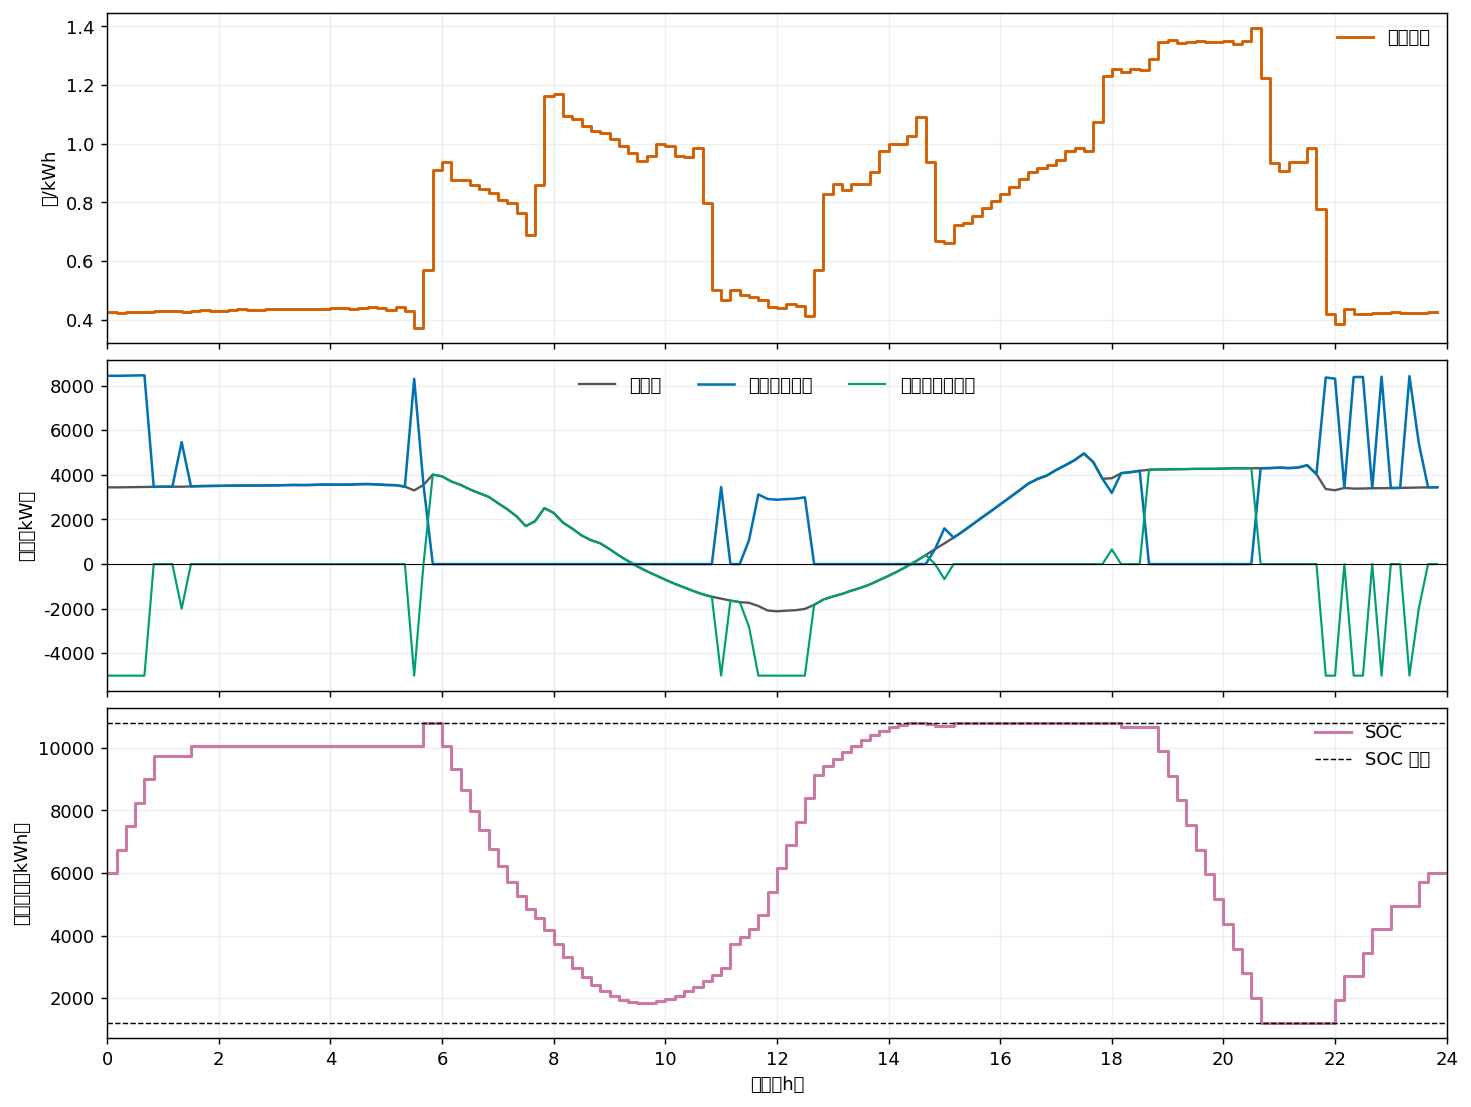

In [5]:

# 逐时明细与题目指定汇总
detail = pd.DataFrame({
    'slot_id': np.arange(1, N+1),
    '自然时间段': natural_intervals,
    '附件时间右端点': cleaned['时间'].astype(str),
    '电价_元每kWh': price,
    '负荷_kWh': load_e,
    '光伏_kWh': pv_e,
    '净负荷_kWh': net_e,
    '计划购电_kWh': g,
    '充电_kWh': c,
    '放电_kWh': discharge,
    'SOC期初_kWh': soc[:-1],
    'SOC期末_kWh': soc[1:],
    '弃电弃光_kWh': solution['spill'],
})

specified_starts = [10, 12, 14, 16, 18, 20]
specified = pd.DataFrame([
    {'时间段': f'{h}:00—{h}:10', '计划购电量_kWh': float(g[h*6])}
    for h in specified_starts
])

blocks = []
for block in range(6):
    lo, hi = 24*block, 24*(block+1)
    blocks.append({
        '时间段': f'{4*block}:00—{4*(block+1)}:00',
        '充电量_kWh': float(c[lo:hi].sum()),
        '放电量_kWh': float(discharge[lo:hi].sum()),
    })
block_summary = pd.DataFrame(blocks)

no_storage_g = np.maximum(net_e, 0.0)
no_storage_cost = float(price @ no_storage_g)
rule_solution = solve_dispatch(
    charge_mask=price <= q25 + 1e-12,
    discharge_mask=price >= q75 - 1e-12,
)
baseline_comparison = pd.DataFrame([
    {'方案': '无储能', '购电量_kWh': no_storage_g.sum(), '总成本_元': no_storage_cost,
     '相对无储能节省率': 0.0},
    {'方案': '简单峰谷规则', '购电量_kWh': rule_solution['g'].sum(),
     '总成本_元': rule_solution['purchase_cost'],
     '相对无储能节省率': 1-rule_solution['purchase_cost']/no_storage_cost},
    {'方案': '完整LP', '购电量_kWh': g.sum(), '总成本_元': solution['purchase_cost'],
     '相对无储能节省率': 1-solution['purchase_cost']/no_storage_cost},
])

display(specified.round(6))
display(block_summary.round(6))
display(baseline_comparison.round(6))

# 最优调度图：价格、供需与储能、SOC 三层对应
fig, axes = plt.subplots(3, 1, figsize=(11.2, 8.4), sharex=True, constrained_layout=True)
axes[0].step(hours, price, where='post', color='#D55E00', lw=1.6, label='分时电价')
axes[0].set_ylabel('元/kWh'); axes[0].legend(frameon=False)

axes[1].plot(hours, net_kw, color='#555555', lw=1.3, label='净负荷')
axes[1].plot(hours, g/DT, color='#0072B2', lw=1.4, label='计划购电功率')
axes[1].plot(hours, (discharge-c)/DT, color='#009E73', lw=1.2, label='储能净放电功率')
axes[1].axhline(0, color='black', lw=.6)
axes[1].set_ylabel('功率（kW）'); axes[1].legend(frameon=False, ncol=3)

axes[2].step(np.arange(N+1)*DT, soc, where='post', color='#CC79A7', lw=1.7, label='SOC')
axes[2].axhline(solution['e_min'], color='black', ls='--', lw=.8, label='SOC 边界')
axes[2].axhline(solution['e_max'], color='black', ls='--', lw=.8)
axes[2].set_ylabel('储能电量（kWh）'); axes[2].set_xlabel('时刻（h）')
axes[2].set_xlim(0,24); axes[2].set_xticks(np.arange(0,25,2)); axes[2].legend(frameon=False)
for ax in axes:
    ax.grid(alpha=.20)
fig.savefig(FIG_DIR/'problem1_dispatch.pdf', bbox_inches='tight')
plt.show()



### 6.2 数值结果解释

| 方案 | 全天成本 | 相对无储能节省率 |
|---|---:|---:|
| 无储能 | 48,052.05 元 | 0 |
| 简单峰谷规则 | 40,289.20 元 | 16.16% |
| 完整 LP | 35,126.95 元 | 26.90% |

完整 LP 比无储能节省 12,925.10 元，比简单规则再节省 5,162.25 元，即相对规则降低 12.81%。完整 LP 的购电量为 59,482.70 kWh，少于无储能的 61,789.94 kWh。这是因为储能吸收了原本会被弃掉的光伏电量；尽管储能存在损耗，更多光伏自用仍能降低外购电量。

题目指定时段的计划购电量为：10:00—10:10 为 0，12:00—12:10 为 480.41245 kWh，14:00—14:10 为 0，16:00—16:10 为 445.43165 kWh，18:00—18:10 为 531.89405 kWh，20:00—20:10 为 0。这里使用自然区间，写入模板时保持附件原行序。

### 6.3 调度图的含义

- **第一层电价图**用于识别储能套利的经济信号。低价时段允许电网低成本充电，高价时段则倾向放电减少购电。
- **第二层供需图**把净负荷、计划购电功率和储能净放电功率放在同一坐标系。绿色曲线大于 0 表示放电，小于 0 表示充电。中午净负荷为负时储能吸收光伏；傍晚和高价时段储能放电。购电曲线不是净负荷的简单复制，说明 SOC 跨时段约束起到了作用。
- **第三层 SOC 图**展示能量转移的累计效果。SOC 在充电时上升、放电时下降，多次触及 1,200 或 10,800 kWh 边界，说明容量约束是有效约束而不是冗余设置；24:00 回到 6,000 kWh，避免了以消耗初始电量换取虚假低成本。

---



## 7. 模型检验

仅凭“求解器成功”不能证明结果可信。本节从五个层面回代检验：

1. **供需平衡：** 将弃电量补回后，检查每个时段等式残差；
2. **SOC 守恒：** 用 $E_t+\eta_cc_t-d_t/\eta_d$ 重新计算下一时段 SOC；
3. **边界可行：** 检查容量、充放电功率、非负性和首尾一致；
4. **行为合理：** 检查是否存在同时充放电；
5. **全局最优：** 用 HiGHS 的对偶边际值计算原始—对偶间隙。

同时统计边界活跃时槽数。活跃约束越多，越能解释容量或功率参数为何会影响成本。具体残差定义为

$$r_t^{\mathrm{bal}}=g_t+P_t^{\mathrm{PV}}\Delta t+d_t-L_t\Delta t-c_t-s_t,$$

$$r_t^{\mathrm{SOC}}=E_{t+1}-E_t-\eta_cc_t+\frac{d_t}{\eta_d},\qquad r^{\mathrm{end}}=E_T-E_0.$$

报告 $\max_t|r_t^{\mathrm{bal}}|$、$\max_t|r_t^{\mathrm{SOC}}|$ 和 $|r^{\mathrm{end}}|$。对于标准 LP，HiGHS 返回等式、不等式及变量边界的对偶乘子，构造对偶目标 $Z_D$；原始目标为 $Z_P$，则

$$\mathrm{Gap}_{\mathrm{abs}}=Z_P-Z_D,\qquad\mathrm{Gap}_{\mathrm{rel}}=\frac{|Z_P-Z_D|}{\max(1,|Z_P|)}.$$

弱对偶性保证 $Z_D\le Z_P$；当原始解可行且间隙在数值容差内为 0 时，即得到全局最优认证。


In [6]:

soc_recomputed = soc[:-1] + BASE_ETA_C*c - discharge/BASE_ETA_D
soc_residual = soc[1:] - soc_recomputed
pcap = BASE_PMAX_KW*DT

checks = {
    'solver_success': bool(solution['solver'].success),
    'solver_status': int(solution['solver'].status),
    'max_power_balance_residual_kWh': float(np.max(np.abs(solution['balance_residual']))),
    'max_soc_recursion_residual_kWh': float(np.max(np.abs(soc_residual))),
    'terminal_soc_error_kWh': float(abs(soc[-1]-soc[0])),
    'soc_lower_violation_kWh': float(max(0.0, solution['e_min']-soc.min())),
    'soc_upper_violation_kWh': float(max(0.0, soc.max()-solution['e_max'])),
    'charge_cap_violation_kWh': float(max(0.0, c.max()-pcap)),
    'discharge_cap_violation_kWh': float(max(0.0, discharge.max()-pcap)),
    'minimum_grid_purchase_kWh': float(g.min()),
    'simultaneous_charge_discharge_slots': int(np.sum((c>1e-7)&(discharge>1e-7))),
    'primal_dual_absolute_gap': float(solution['primal_dual_gap']),
    'primal_dual_relative_gap': float(solution['relative_gap']),
}

active_constraints = {
    'SOC在下界的时点数': int(np.sum(np.isclose(soc, solution['e_min'], atol=1e-6))),
    'SOC在上界的时点数': int(np.sum(np.isclose(soc, solution['e_max'], atol=1e-6))),
    '充电达到功率上限的时槽数': int(np.sum(np.isclose(c, pcap, atol=1e-6))),
    '放电达到功率上限的时槽数': int(np.sum(np.isclose(discharge, pcap, atol=1e-6))),
    '购电量为零的时槽数': int(np.sum(g<1e-7)),
    '发生弃电弃光的时槽数': int(np.sum(solution['spill']>1e-7)),
}

assert checks['solver_success']
assert checks['max_power_balance_residual_kWh'] < 1e-6
assert checks['max_soc_recursion_residual_kWh'] < 1e-6
assert checks['terminal_soc_error_kWh'] < 1e-6
assert checks['soc_lower_violation_kWh'] < 1e-6
assert checks['soc_upper_violation_kWh'] < 1e-6
assert checks['charge_cap_violation_kWh'] < 1e-6
assert checks['discharge_cap_violation_kWh'] < 1e-6
assert checks['minimum_grid_purchase_kWh'] >= -1e-8
assert checks['simultaneous_charge_discharge_slots'] == 0
assert checks['primal_dual_relative_gap'] < 1e-10

evaluation = pd.DataFrame([
    {'检验': '功率平衡', '统计量': checks['max_power_balance_residual_kWh'], '判定阈值': '<1e-6 kWh', '结论': '通过'},
    {'检验': 'SOC递推', '统计量': checks['max_soc_recursion_residual_kWh'], '判定阈值': '<1e-6 kWh', '结论': '通过'},
    {'检验': '首尾SOC', '统计量': checks['terminal_soc_error_kWh'], '判定阈值': '<1e-6 kWh', '结论': '通过'},
    {'检验': 'LP原始-对偶相对间隙', '统计量': checks['primal_dual_relative_gap'], '判定阈值': '<1e-10', '结论': '通过'},
    {'检验': '同时充放电时槽数', '统计量': checks['simultaneous_charge_discharge_slots'], '判定阈值': '=0', '结论': '通过'},
])
evaluation.to_csv(RESULT_DIR/'problem1_evaluation.csv', index=False, encoding='utf-8-sig')
pd.DataFrame([checks]).to_csv(RESULT_DIR/'problem1_constraint_checks.csv', index=False, encoding='utf-8-sig')
pd.DataFrame([active_constraints]).to_csv(RESULT_DIR/'problem1_active_constraints.csv', index=False, encoding='utf-8-sig')

display(evaluation)
display(pd.Series(checks, name='约束回代结果').to_frame())
display(pd.Series(active_constraints, name='活跃约束统计').to_frame())


,检验,统计量,判定阈值,结论
0,功率平衡,1.492140e-13,<1e-6 kWh,通过
1,SOC递推,9.094947e-13,<1e-6 kWh,通过
2,首尾SOC,0.000000e+00,<1e-6 kWh,通过
3,LP原始-对偶相对间隙,2.071332e-15,<1e-10,通过
4,同时充放电时槽数,0.000000e+00,=0,通过


,约束回代结果
solver_success,True
solver_status,0
max_power_balance_residual_kWh,0.0
max_soc_recursion_residual_kWh,0.0
terminal_soc_error_kWh,0.0
soc_lower_violation_kWh,0.0
soc_upper_violation_kWh,0.0
charge_cap_violation_kWh,0.0
discharge_cap_violation_kWh,0.0
minimum_grid_purchase_kWh,0.0


,活跃约束统计
SOC在下界的时点数,8
SOC在上界的时点数,21
充电达到功率上限的时槽数,19
放电达到功率上限的时槽数,0
购电量为零的时槽数,58
发生弃电弃光的时槽数,0



### 7.1 检验结论

- 最大功率平衡残差为 $1.49\times10^{-13}$ kWh；
- 最大 SOC 递推残差为 $9.09\times10^{-13}$ kWh；
- 日初、日末 SOC 误差为 0；
- SOC 全程位于 1,200—10,800 kWh，充放电均未超过 833.3333 kWh/时槽；
- 同时充放电时槽数为 0；
- 原始—对偶绝对间隙约为 $8.00\times10^{-11}$，相对间隙约为 $2.28\times10^{-15}$。

因此，结果在数值容差内严格满足物理约束，且达到 LP 的全局最优。无储能和规则 baseline 证明了经济有效性；约束回代和对偶间隙则分别证明了可行性和最优性。

---



## 8. 敏感性分析

### 8.1 实验设计

采用一次只改变一个参数的 OFAT（One Factor At a Time）设计，其余参数保持基准值：

| 参数 | 试验值 | 物理含义 |
|---|---|---|
| 单向效率 $\eta_c=\eta_d$ | 0.85、0.90、0.95、1.00 | 损耗大小 |
| 最大充放电功率 $P_{\max}$ | 3,000、4,000、5,000、6,000、7,000 kW | 单时段能量转移速度 |
| 额定容量 $C$ | 8,000、10,000、12,000、14,000、16,000 kWh | 跨时段可搬移的能量规模 |

改变容量时仍保持 10%—90% SOC 运行区间，以及 50% 的日初、日末 SOC。每一个参数点都重新建立并求解完整 LP，而不是在基准解上做事后缩放。评价指标为购电成本 $C(\theta)$ 和相对无储能节省率

$$R_{\mathrm{save}}(\theta)=1-\frac{C(\theta)}{C_0},$$

其中 $\theta$ 依次代表效率、功率或容量参数。


,参数,取值,取值单位,购电成本_元,购电量_kWh,相对无储能节省率
0,单向效率,0.85,-,36603.406480,61728.975125,0.238255
1,单向效率,0.90,-,35126.948589,59482.698998,0.268981
2,单向效率,0.95,-,33767.032621,57472.643101,0.297282
3,单向效率,1.00,-,32377.088241,55541.972433,0.326208
4,最大功率,3000.00,kW,35788.440070,59215.288152,0.255215
5,最大功率,4000.00,kW,35247.870900,59482.326688,0.266465
6,最大功率,5000.00,kW,35126.948589,59482.698998,0.268981
7,最大功率,6000.00,kW,35083.293480,59482.698998,0.269890
8,最大功率,7000.00,kW,35044.587160,59557.196870,0.270695
9,额定容量,8000.00,kWh,37970.290579,58265.564116,0.209809


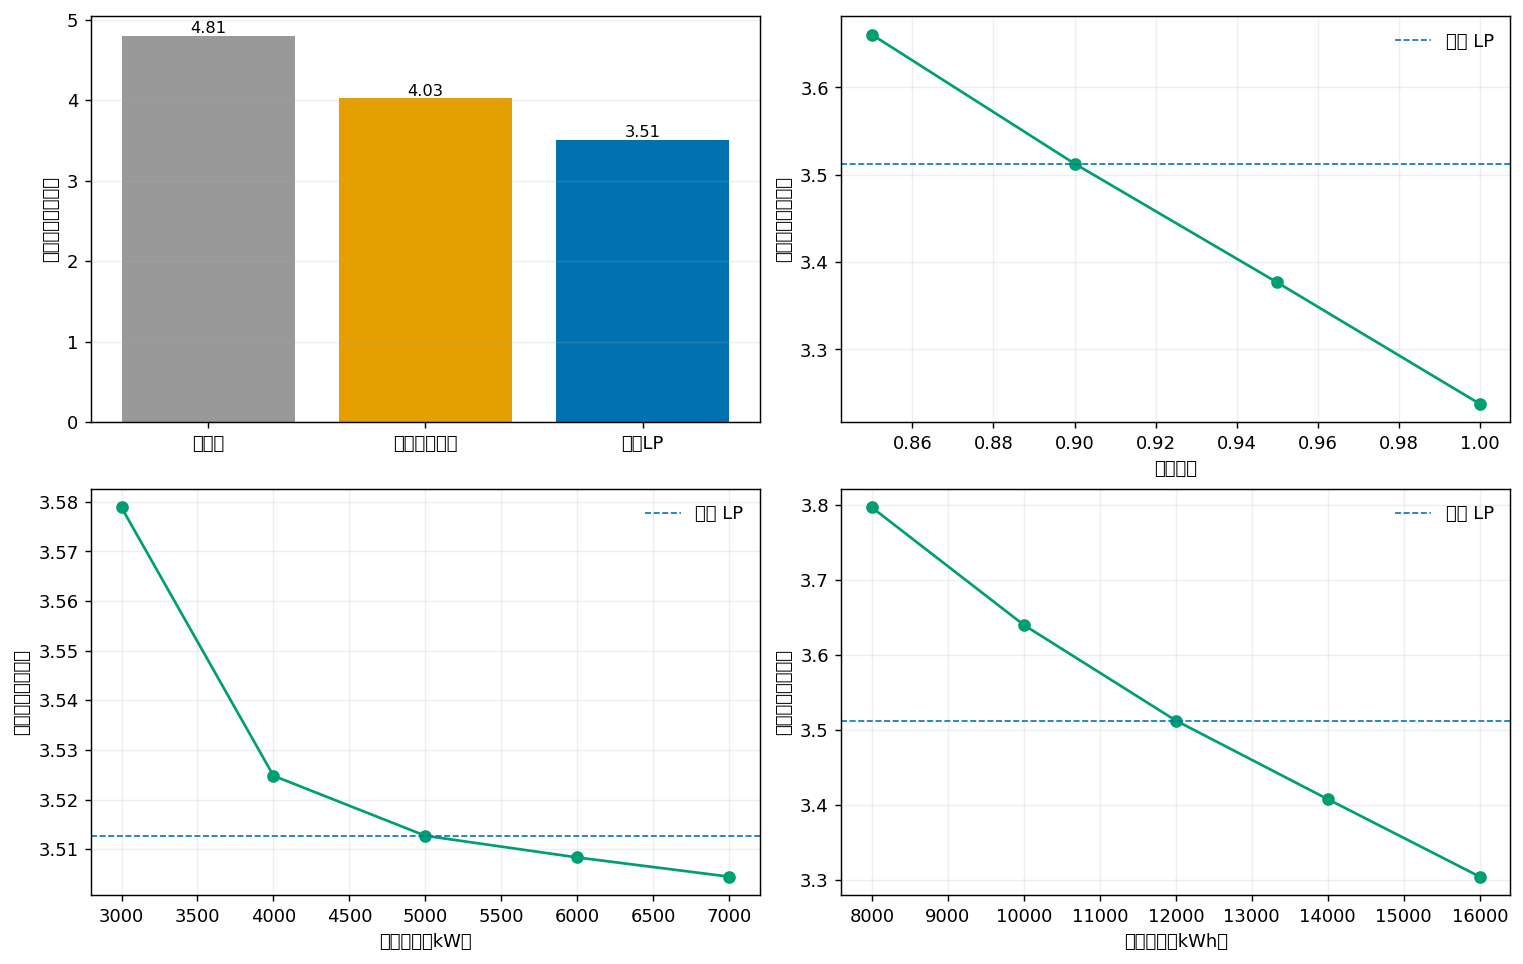

In [7]:

sensitivity_rows = []

for eta in [0.85, 0.90, 0.95, 1.00]:
    z = solve_dispatch(eta_c=eta, eta_d=eta)
    sensitivity_rows.append({
        '参数': '单向效率', '取值': eta, '取值单位': '-',
        '购电成本_元': z['purchase_cost'],
        '购电量_kWh': z['g'].sum(),
        '相对无储能节省率': 1-z['purchase_cost']/no_storage_cost,
    })

for pmax in [3000, 4000, 5000, 6000, 7000]:
    z = solve_dispatch(pmax_kw=pmax)
    sensitivity_rows.append({
        '参数': '最大功率', '取值': pmax, '取值单位': 'kW',
        '购电成本_元': z['purchase_cost'],
        '购电量_kWh': z['g'].sum(),
        '相对无储能节省率': 1-z['purchase_cost']/no_storage_cost,
    })

for capacity in [8000, 10000, 12000, 14000, 16000]:
    z = solve_dispatch(capacity_kwh=capacity)
    sensitivity_rows.append({
        '参数': '额定容量', '取值': capacity, '取值单位': 'kWh',
        '购电成本_元': z['purchase_cost'],
        '购电量_kWh': z['g'].sum(),
        '相对无储能节省率': 1-z['purchase_cost']/no_storage_cost,
    })

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.to_csv(RESULT_DIR/'problem1_sensitivity_full.csv', index=False, encoding='utf-8-sig')
sensitivity[sensitivity['参数']=='单向效率'].to_csv(
    RESULT_DIR/'problem1_efficiency_sensitivity.csv', index=False, encoding='utf-8-sig')
baseline_comparison.to_csv(RESULT_DIR/'problem1_baseline_comparison.csv', index=False, encoding='utf-8-sig')
display(sensitivity.round(6))

fig, axes = plt.subplots(2, 2, figsize=(11.6, 7.3), constrained_layout=True)

# (a) 三方案经济性比较
axes[0,0].bar(baseline_comparison['方案'], baseline_comparison['总成本_元']/1e4,
              color=['#999999','#E69F00','#0072B2'])
axes[0,0].set_ylabel('购电成本（万元）'); axes[0,0].grid(axis='x', visible=False)
for i, value in enumerate(baseline_comparison['总成本_元']/1e4):
    axes[0,0].text(i, value+.03, f'{value:.2f}', ha='center', fontsize=9)

plot_specs = [
    ('单向效率', '单向效率', '-'),
    ('最大功率', '最大功率', 'kW'),
    ('额定容量', '额定容量', 'kWh'),
]
for ax, (key, label, unit) in zip(axes.flat[1:], plot_specs):
    s = sensitivity[sensitivity['参数']==key]
    ax.plot(s['取值'], s['购电成本_元']/1e4, color='#009E73', marker='o', lw=1.5)
    ax.axhline(solution['purchase_cost']/1e4, color='#0072B2', ls='--', lw=.9, label='基准 LP')
    ax.set_xlabel(label if unit=='-' else f'{label}（{unit}）')
    ax.set_ylabel('购电成本（万元）'); ax.legend(frameon=False)
    ax.grid(alpha=.20)

fig.savefig(FIG_DIR/'problem1_evaluation_sensitivity.pdf', bbox_inches='tight')
plt.show()



### 8.2 敏感性图的含义与结论

- **左上图：baseline 比较。** 该图证明储能本身有经济价值，同时证明完整 LP 比固定峰谷窗口更能利用光伏、连续价格和 SOC 信息。
- **右上图：效率敏感性。** 单向效率从 0.85 提高到 1.00，购电成本从 36,603.41 元连续下降到 32,377.09 元，节省率由 23.83% 增至 32.62%。方向符合“损耗越小、可利用能量越多”的物理规律。
- **左下图：功率敏感性。** 最大功率从 3,000 提高到 7,000 kW，成本从 35,788.44 元下降到 35,044.59 元；超过基准 5,000 kW 后曲线趋缓，说明继续增加功率的边际收益有限。
- **右下图：容量敏感性。** 容量从 8,000 增至 16,000 kWh，成本从 37,970.29 元下降到 33,043.69 元，节省率由 20.98% 增至 31.23%。在当前数据下，容量对跨时段能量搬移的影响比功率更明显。

所有敏感性情景都获得可行最优解，目标值随效率、功率和容量变化的方向连续、合理，没有出现参数小幅变化导致结果突变或模型不可行的现象。因此主结论具有稳定性。需要注意，曲线只反映运行购电费，没有包含扩容投资成本，不能据此直接断言容量越大越好；若做设备选型，应进一步加入年化投资和退化成本。

---



## 9. 模型评价、局限与推广

### 9.1 模型优点

1. **物理含义清楚：** 每个变量都有明确单位，供需平衡和 SOC 递推可逐时回代。
2. **求解结论强：** 连续 LP 可获得全局最优，并能利用对偶间隙认证最优性。
3. **结果可解释：** 调度图能直接解释低价充电、光伏吸收和高价放电。
4. **评价链完整：** 同时具备无储能 baseline、规则 baseline、约束检验和三类敏感性。
5. **可复现：** 数据读取、矩阵构造、求解、作图、CSV/JSON 和 Excel 写入全部在一个 notebook 内完成。

### 9.2 模型局限

1. 问题 1 使用题目给出的确定性负荷与光伏预测，没有描述预测偏差；这一不确定性在问题 2 中处理。
2. 未计入电池循环退化、运维和投资成本，因为题目没有给出可靠参数。
3. 假设充放电效率在各功率区间内恒定，未考虑温度和 SOC 对效率的非线性影响。
4. 允许免费弃光且不允许售电；若实际规则允许上网，应增加售电变量和上网电价。
5. 当前模型面向单个微网；推广到多微网时可加入联络线容量、节点功率平衡和配电网约束，仍可形成 LP 或凸优化模型。

---



## 10. 结果文件生成与最终一致性检查

最后将论文引用的全部数值写入 CSV/JSON，并按附件 5 模板生成 `result1.xlsx`。写入后重新读取 Excel，逐格核对 144 个购电量，防止模板位置或浮点写入错误。


In [8]:

# 保存中间表和结果记录
detail.to_csv(RESULT_DIR/'problem1_interval_detail.csv', index=False, encoding='utf-8-sig')
specified.to_csv(RESULT_DIR/'problem1_specified_intervals.csv', index=False, encoding='utf-8-sig')
block_summary.to_csv(RESULT_DIR/'problem1_four_hour_summary.csv', index=False, encoding='utf-8-sig')

summary = {
    'problem': 1,
    'model': 'deterministic_linear_program',
    'time_convention': '附件时间为区间右端点；按原144行顺序对应自然区间并写入模板',
    'data_quality': quality.to_dict('records'),
    'parameters': {
        'slots': N, 'dt_hours': DT, 'capacity_kwh': BASE_CAPACITY,
        'soc_bounds_kwh': [0.1*BASE_CAPACITY, 0.9*BASE_CAPACITY],
        'initial_terminal_soc_kwh': 0.5*BASE_CAPACITY,
        'max_power_kw': BASE_PMAX_KW,
        'max_energy_per_slot_kwh': BASE_PMAX_KW*DT,
        'eta_charge': BASE_ETA_C, 'eta_discharge': BASE_ETA_D,
        'throughput_tiebreak': THROUGHPUT_EPS,
    },
    'planned_purchase_kWh': float(g.sum()),
    'planned_cost_yuan': float(solution['purchase_cost']),
    'no_storage_purchase_kWh': float(no_storage_g.sum()),
    'no_storage_cost_yuan': float(no_storage_cost),
    'cost_saving_yuan': float(no_storage_cost-solution['purchase_cost']),
    'cost_saving_rate': float(1-solution['purchase_cost']/no_storage_cost),
    'total_charge_kWh': float(c.sum()),
    'total_discharge_kWh': float(discharge.sum()),
    'specified_intervals': specified.to_dict('records'),
    'four_hour_blocks': block_summary.to_dict('records'),
    'eda_metrics': eda_metrics.to_dict('records'),
    'baseline_comparison': baseline_comparison.to_dict('records'),
    'checks': checks,
    'active_constraints': active_constraints,
    'sensitivity': sensitivity.to_dict('records'),
}
with open(RESULT_DIR/'problem1_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

# 按附件 5 原模板写入结果
output_path = ROOT/'result1.xlsx'
shutil.copy2(TEMPLATE_PATH, output_path)
wb = load_workbook(output_path)
ws_plan = wb['计划购电量']
assert ws_plan.max_row == 145
for row, value in enumerate(g, start=2):
    ws_plan.cell(row, 2).value = round(float(value), 6)

ws_storage = wb['充放电量']
for row, record in enumerate(blocks, start=2):
    ws_storage.cell(row, 2).value = round(record['充电量_kWh'], 6)
    ws_storage.cell(row, 3).value = round(record['放电量_kWh'], 6)
ws_storage['E2'] = round(float(soc[0]), 6)
ws_storage['E3'] = round(float(soc[-1]), 6)
wb.save(output_path)

# 回读并逐格验收
check_wb = load_workbook(output_path, data_only=False, read_only=True)
excel_g = np.array([check_wb['计划购电量'].cell(r,2).value for r in range(2,146)], float)
check_wb.close()
excel_max_error = float(np.max(np.abs(excel_g-g)))
assert excel_g.shape == (N,) and excel_max_error < 5e-7

deliverables = pd.DataFrame([
    {'产物': '提交结果', '路径': str(output_path), '状态': '已生成并逐格核对'},
    {'产物': '区间明细', '路径': str(RESULT_DIR/'problem1_interval_detail.csv'), '状态': '已生成'},
    {'产物': '汇总JSON', '路径': str(RESULT_DIR/'problem1_summary.json'), '状态': '已生成'},
    {'产物': 'EDA图', '路径': str(FIG_DIR/'problem1_eda.pdf'), '状态': '已生成'},
    {'产物': '调度图', '路径': str(FIG_DIR/'problem1_dispatch.pdf'), '状态': '已生成'},
    {'产物': '评价与敏感性图', '路径': str(FIG_DIR/'problem1_evaluation_sensitivity.pdf'), '状态': '已生成'},
])
display(deliverables)
print(f'Excel 计划购电量最大回读误差：{excel_max_error:.3e} kWh')
print('问题 1 全链路运行完成，所有断言均通过。')


,产物,路径,状态
0,提交结果,/content/result1.xlsx,已生成并逐格核对
1,区间明细,/content/results/problem1_interval_detail.csv,已生成
2,汇总JSON,/content/results/problem1_summary.json,已生成
3,EDA图,/content/figures/problem1_eda.pdf,已生成
4,调度图,/content/figures/problem1_dispatch.pdf,已生成
5,评价与敏感性图,/content/figures/problem1_evaluation_sensitivi...,已生成


Excel 计划购电量最大回读误差：3.992e-07 kWh
问题 1 全链路运行完成，所有断言均通过。
